# HA-only Checkpoint 推理

加载指定 checkpoint（`.pth`），在 `test.csv` 上做推理并导出预测结果。

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ===== 路径配置（按需修改）=====
REPO_ROOT = Path('/home/chenyh/workspace/fluProfiler')
CHECKPOINT_PATH = REPO_ROOT / 'runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/checkpoints/2026-03-22_21-21-28.pth'
CSV_PATH = REPO_ROOT / 'data/HA_only/split/test.csv'
EMBEDDING_ROOT = REPO_ROOT / 'data/reverse_test/embedding'
OUTPUT_PRED_CSV = REPO_ROOT / 'runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/test_predictions.csv'

BATCH_SIZE = 64
GPU_CACHE_GB = 28
DEVICE = 'cuda:1'  # 没有 GPU 可改成 'cpu'
ADD_SPECIAL_TOKEN = True

# 本地模块路径
sys.path.append(str(REPO_ROOT / 'src' / 'fluprofiler'))
sys.path.append(str(REPO_ROOT / 'experiments' / 'reverse_tests'))

from experiment_tools import GpuEmbeddingCache, convert_Pass2tensor, generate_matrix_on_device
from data.loaders import load_embedding
from evaluation.metrics import print_exams

print('checkpoint:', CHECKPOINT_PATH)
print('csv:', CSV_PATH)
print('embedding_root:', EMBEDDING_ROOT)

checkpoint: /home/chenyh/workspace/fluProfiler/runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/checkpoints/2026-03-22_21-21-28.pth
csv: /home/chenyh/workspace/fluProfiler/data/HA_only/split/test.csv
embedding_root: /home/chenyh/workspace/fluProfiler/data/reverse_test/embedding


In [2]:
class HAOnlyInferenceDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, add_special_token: bool = True):
        self.df = dataframe.reset_index(drop=True)
        self.emb_file_name_a = ('matrix_' + self.df['seq_id_a']).tolist()
        self.emb_file_name_c = ('matrix_' + self.df['seq_id_c']).tolist()
        if add_special_token:
            self.strainPassCats = convert_Pass2tensor(
                (
                    '<cls>'
                    + self.df['serumPassCat']
                    + '<eos>'
                    + self.df['virusPassCat']
                    + '<eos>'
                ).tolist()
            )
        else:
            self.strainPassCats = convert_Pass2tensor(
                (self.df['serumPassCat'] + self.df['virusPassCat']).tolist()
            )
        self.labels = torch.tensor(self.df['label'].tolist(), dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return (
            self.emb_file_name_a[idx],
            self.emb_file_name_c[idx],
            self.strainPassCats[idx],
            self.labels[idx],
        )


from tqdm.auto import tqdm

def run_inference(model, dataloader, device, cache, show_progress=True):
    model.eval()
    preds, refs = [], []
    iterator = tqdm(dataloader, total=len(dataloader), desc="Inference") if show_progress else dataloader

    with torch.no_grad():
        for batch in iterator:
            emb_file_name_a, emb_file_name_c, strainPassCats, labels = batch
            matrices_a_list = [cache.get(key) for key in emb_file_name_a]
            matrices_c_list = [cache.get(key) for key in emb_file_name_c]
            matrixs_a, masks_a = generate_matrix_on_device(matrices_a_list, device=device)
            matrixs_c, masks_c = generate_matrix_on_device(matrices_c_list, device=device)
            strainPassCats = strainPassCats.to(device)
            labels = labels.to(device)

            logits, output = model(
                matrices_a=matrixs_a,
                matrices_c=matrixs_c,
                matrix_attention_masks_a=masks_a,
                matrix_attention_masks_c=masks_c,
                strainPassCats=strainPassCats,
                labels=None,
            )

            preds.extend(output.view(-1).tolist())
            refs.extend(labels.tolist())

    return refs, preds

In [3]:
device = torch.device(DEVICE)

# 1) 读测试集
inference_df = pd.read_csv('/home/chenyh/workspace/fluProfiler_back3/data/processing/epistrains_h3n2/normalize/H3N2_HA_cluster99.csv')
print('test rows:', len(inference_df))

test rows: 4868760


In [4]:
inference_df = inference_df.iloc[:int(len(inference_df)/2),:]

In [5]:
inference_df.columns = ['seq_id_a', 'seq_id_c', 'seq_a', 'seq_c', 'serumPassCat', 'virusPassCat', 'Type']
inference_df['label'] = 0

In [6]:
# 2) 仅加载推理所需 embedding
sequence_names = pd.concat([inference_df['seq_id_a'], inference_df['seq_id_c']]).unique().tolist()
embedding_files = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict = load_embedding("/home/chenyh/workspace/fluProfiler_back3/workplace/dms_experiment/20260323meeting/embedding", files=embedding_files)

Loading tensor: 100%|██████████| 3121/3121 [02:21<00:00, 22.10file/s]


In [7]:
max_cache_bytes = int(GPU_CACHE_GB * 1024**3)
gpu_cache = GpuEmbeddingCache(cpu_store=emb_dict, device=device, max_bytes=max_cache_bytes)

# 3) DataLoader
dataset = HAOnlyInferenceDataset(inference_df, add_special_token=ADD_SPECIAL_TOKEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
print('serum count', len(inference_df['seq_id_a'].unique()))
print('virus count', len(inference_df['seq_id_c'].unique()))

serum count 914
virus count 3120


In [9]:
# 4) 加载模型（该 checkpoint 为 torch.save(model, ...)，直接 torch.load）
model = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.to(device)
model.eval()

# 5) 推理
refs, preds = run_inference(model, dataloader, device, gpu_cache)

# 6) 指标
mae, mse, pearson, spearman, r2 = print_exams(refs, preds, print_result=True)

# 7) 保存预测
out_df = inference_df.copy()
out_df['pred'] = preds
OUTPUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUTPUT_PRED_CSV, index=False)
print('saved:', OUTPUT_PRED_CSV)

# 8) 打印缓存统计
print(f"[cache] hits={gpu_cache.hits}, misses={gpu_cache.misses}, copied_GB={gpu_cache.copied_bytes/(1024**3):.2f}")

Inference:   0%|          | 0/38038 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
import pandas as pd

former = pd.read_csv('/home/chenyh/workspace/fluProfiler/experiments/HA_only/test_predictions_fommer.csv')
latter = pd.read_csv('/home/chenyh/workspace/fluProfiler/experiments/HA_only/test_predictions.csv')

In [6]:
all = pd.concat([former, latter])

In [10]:
# 1) 对每个 seq_id_a，计算它和所有 seq_id_c 的 prediction 平均值
a_mean_pred = (
    all.groupby("seq_id_a", as_index=False)["pred"]
    .mean()
    .rename(columns={"pred": "mean_pred"})
)

# 2) 找平均 prediction 最小的 seq_id_a
best_row = a_mean_pred.loc[a_mean_pred["mean_pred"].idxmin()]
best_seq_id_a = best_row["seq_id_a"]
best_mean_pred = best_row["mean_pred"]

print("最小平均 prediction 的 seq_id_a:", best_seq_id_a)
print("对应平均 prediction:", best_mean_pred)

# 3) 如果想看前10个最小
display(a_mean_pred.sort_values("mean_pred").head(10))

最小平均 prediction 的 seq_id_a: EPI3544994
对应平均 prediction: -0.02561192398430471


,seq_id_a,mean_pred
1656,EPI3544994,-0.025612
2017,EPI401749,0.340675
2152,EPI4253820,0.384167
1855,EPI3731978,0.493942
1892,EPI3786347,0.534897
2441,EPI4769655,0.549331
2667,EPI537057,0.561458
1897,EPI3790479,0.575546
2407,EPI4725774,0.580569
1901,EPI3794940,0.590054


rows: 441
unique seq_id_c: 441
pred mean: -0.025611923984304712
pred min : -2.246657371520996
pred max : 3.409486055374145


/home/chenyh/miniconda3/envs/fluProfiler/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


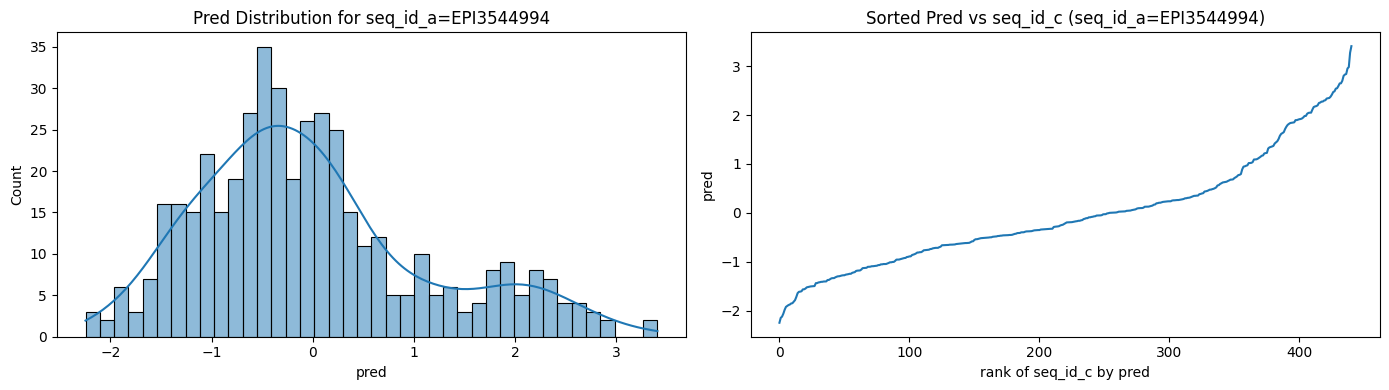

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

target_a = "EPI3544994"
sub = all[all["seq_id_a"] == target_a].copy()

print("rows:", len(sub))
print("unique seq_id_c:", sub["seq_id_c"].nunique())
print("pred mean:", sub["pred"].mean())
print("pred min :", sub["pred"].min())
print("pred max :", sub["pred"].max())

# 按 pred 排序，便于看极值
sub_sorted = sub.sort_values("pred").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1) 分布图
sns.histplot(sub["pred"], bins=40, kde=True, ax=axes[0])
axes[0].set_title(f"Pred Distribution for seq_id_a={target_a}")
axes[0].set_xlabel("pred")

# 2) 排序折线图（每个点对应一个 seq_id_c）
axes[1].plot(sub_sorted.index, sub_sorted["pred"], linewidth=1.5)
axes[1].set_title(f"Sorted Pred vs seq_id_c (seq_id_a={target_a})")
axes[1].set_xlabel("rank of seq_id_c by pred")
axes[1].set_ylabel("pred")

plt.tight_layout()
plt.show()

In [13]:
all['pred']

0          1.096738
1          0.070444
2         -0.503800
3          1.265834
4          0.445427
             ...   
2434375    0.853660
2434376    0.528555
2434377    1.387081
2434378    0.731312
2434379    1.132508
Name: pred, Length: 4868760, dtype: float64

count: 4868760
mean : 3.0919072968553336
std  : 1.5386599274798023
min  : -4.110558986663818
q01  : -0.2660595762729644
q05  : 0.6024430811405183
q50  : 2.997433662414551
q95  : 5.578245854377746
q99  : 6.4464395093917854
max  : 9.957746505737305


/home/chenyh/miniconda3/envs/fluProfiler/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


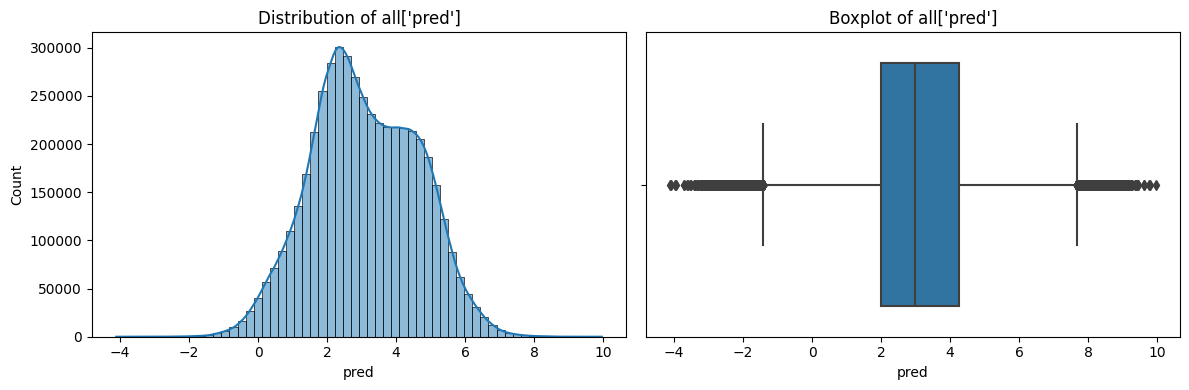

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pred = all["pred"].dropna()

print("count:", pred.shape[0])
print("mean :", pred.mean())
print("std  :", pred.std())
print("min  :", pred.min())
print("q01  :", pred.quantile(0.01))
print("q05  :", pred.quantile(0.05))
print("q50  :", pred.median())
print("q95  :", pred.quantile(0.95))
print("q99  :", pred.quantile(0.99))
print("max  :", pred.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(pred, bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of all['pred']")
axes[0].set_xlabel("pred")

sns.boxplot(x=pred, ax=axes[1])
axes[1].set_title("Boxplot of all['pred']")
axes[1].set_xlabel("pred")

plt.tight_layout()
plt.show()